# 🎙️ Emotion Detection — Étape 5 : Wav2Vec2 Fine-tuning
**Idée :** Wav2Vec2 est pré-entraîné sur 960h de parole (LibriSpeech). On remplace seulement la tête de classification pour nos 8 émotions.

```
Audio brut (signal 1D) 
       ↓
Wav2Vec2 feature extractor   ← CNN interne, frozen
       ↓
Wav2Vec2 transformer (12 couches)  ← fine-tuné
       ↓
Mean pooling sur le temps
       ↓
Classifier → 8 émotions
```

---
## 📦 Cellule 1 — Installation & Imports

In [69]:
# Installation des librairies HuggingFace
!pip install -q transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.5 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [70]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Wav2Vec2Model,
    Wav2Vec2FeatureExtractor,
)
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

EMOTIONS  = ['angry','calm','disgust','fearful','happy','neutral','sad','surprised']
NUM_CLASS = len(EMOTIONS)
LABEL2ID  = {e: i for i, e in enumerate(EMOTIONS)}
OUT       = '/kaggle/working'
RAVDESS_PATH = '/kaggle/input/datasets/elouardaniilyasse/ravdess/RAVDESS'
SR        = 16000

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'✅ Imports OK | Seed {SEED}')

✅ Device : cuda
   GPU : Tesla T4
   VRAM : 15.6 GB
✅ Imports OK | Seed 42


---
## 📂 Cellule 2 — Chargement du DataFrame RAVDESS

In [71]:
EMOTIONS_MAP = {
    '01': 'neutral',  '02': 'calm',
    '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful',
    '07': 'disgust',  '08': 'surprised'
}

records = []
for actor_folder in sorted(os.listdir(RAVDESS_PATH)):
    actor_path = os.path.join(RAVDESS_PATH, actor_folder)
    if not os.path.isdir(actor_path):
        continue
    for filename in os.listdir(actor_path):
        if not filename.endswith('.wav'):
            continue
        parts    = filename.replace('.wav', '').split('-')
        if len(parts) < 7:
            continue
        emotion  = EMOTIONS_MAP.get(parts[2], 'unknown')
        actor_id = int(parts[6])
        if emotion == 'unknown':
            continue
        records.append({
            'path'   : os.path.join(actor_path, filename),
            'emotion': emotion,
            'label'  : LABEL2ID[emotion],
            'actor'  : actor_id,
        })

df = pd.DataFrame(records).sort_values('actor').reset_index(drop=True)

# Split par acteur — train:1-16 | val:17-20 | test:21-24
df_train = df[df['actor'] <= 16].reset_index(drop=True)
df_val   = df[(df['actor'] > 16) & (df['actor'] <= 20)].reset_index(drop=True)
df_test  = df[df['actor'] > 20].reset_index(drop=True)

print(f'✅ {len(df)} fichiers | Train:{len(df_train)} | Val:{len(df_val)} | Test:{len(df_test)}')
print(f'   Pas d\'augmentation — Wav2Vec2 n\'en a pas besoin')

✅ 1440 fichiers | Train:960 | Val:240 | Test:240
   Pas d'augmentation — Wav2Vec2 n'en a pas besoin


---
## ⚖️ Cellule 3 — Class weights

In [72]:
label_counts = Counter(df_train['label'].tolist())
total        = sum(label_counts.values())

weights = torch.tensor([
    total / (NUM_CLASS * label_counts[i])
    for i in range(NUM_CLASS)
], dtype=torch.float32).to(device)

print('Class weights :')
for emo, w in zip(EMOTIONS, weights):
    print(f'  {emo:<12} {w:.3f}')

Class weights :
  angry        0.938
  calm         0.938
  disgust      0.938
  fearful      0.938
  happy        0.938
  neutral      1.875
  sad          0.938
  surprised    0.938


---
## 🔧 Cellule 4 — Feature extractor Wav2Vec2

In [73]:
MODEL_NAME = 'facebook/wav2vec2-base'

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)

print(f'✅ Feature extractor chargé : {MODEL_NAME}')
print(f'   Sampling rate attendu : {feature_extractor.sampling_rate} Hz')

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

✅ Feature extractor chargé : facebook/wav2vec2-base
   Sampling rate attendu : 16000 Hz


---
## 🗂️ Cellule 5 — Dataset audio brut (signal 1D)

In [74]:
MAX_DURATION = 4.0   # secondes
MAX_SAMPLES  = int(SR * MAX_DURATION)  # 64000


class RAVDESSDataset(Dataset):
    """
    Charge le signal audio brut (1D) et le prépare pour Wav2Vec2.
    Pas de mel-spectrogramme — Wav2Vec2 travaille directement sur le signal.
    """
    def __init__(self, df, feature_extractor, max_samples=MAX_SAMPLES):
        self.df                = df
        self.feature_extractor = feature_extractor
        self.max_samples       = max_samples

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio, _ = librosa.load(row['path'], sr=SR, mono=True)

        # Normalisation amplitude
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        # Trim silence
        audio, _ = librosa.effects.trim(audio, top_db=20)

        # Padding / découpage
        if len(audio) < self.max_samples:
            pad   = self.max_samples - len(audio)
            audio = np.pad(audio, (pad // 2, pad - pad // 2))
        else:
            start = (len(audio) - self.max_samples) // 2
            audio = audio[start: start + self.max_samples]

        # Feature extractor Wav2Vec2
        inputs = self.feature_extractor(
            audio,
            sampling_rate=SR,
            return_tensors='pt',
            padding=False,
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),  # (64000,)
            'label'       : torch.tensor(row['label'], dtype=torch.long),
        }


BATCH_SIZE = 8   # ✅ petit batch car Wav2Vec2 est lourd en mémoire

train_dataset = RAVDESSDataset(df_train, feature_extractor)
val_dataset   = RAVDESSDataset(df_val,   feature_extractor)
test_dataset  = RAVDESSDataset(df_test,  feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'✅ Datasets prêts')
print(f'   Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}')
print(f'   Batch size : {BATCH_SIZE} (réduit pour VRAM)')

# Test d'un batch
batch = next(iter(train_loader))
print(f'\n   input_values shape : {batch["input_values"].shape}')  # (8, 64000)

✅ Datasets prêts
   Train : 960 | Val : 240 | Test : 240
   Batch size : 8 (réduit pour VRAM)

   input_values shape : torch.Size([8, 64000])


---
## 🧠 Cellule 6 — Modèle Wav2Vec2 + tête de classification

In [75]:
class Wav2Vec2ForSER(nn.Module):
    """
    Wav2Vec2 pré-entraîné + classifier pour Speech Emotion Recognition.
    Stratégie : geler le feature extractor CNN, fine-tuner les transformers.
    """
    def __init__(self, model_name, num_classes=8, dropout=0.1):
        super().__init__()

        # Chargement du modèle pré-entraîné
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name)

        # ✅ Geler le feature extractor CNN (économise mémoire + évite overfit)
        self.wav2vec2.feature_extractor._freeze_parameters()

        hidden_size = self.wav2vec2.config.hidden_size  # 768 pour wav2vec2-base

        # Tête de classification
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_values):
        # Wav2Vec2 → (B, T, 768)
        outputs = self.wav2vec2(input_values)
        hidden  = outputs.last_hidden_state   # (B, T, 768)

        # ✅ Mean pooling sur la dimension temporelle
        pooled  = hidden.mean(dim=1)          # (B, 768)

        return self.classifier(pooled)         # (B, 8)


model = Wav2Vec2ForSER(MODEL_NAME, num_classes=NUM_CLASS).to(device)

# Compter les paramètres
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f'✅ Modèle Wav2Vec2ForSER chargé')
print(f'   Paramètres totaux     : {total:,}')
print(f'   Paramètres entraîn.   : {trainable:,}')
print(f'   Paramètres gelés      : {frozen:,} (feature extractor CNN)')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle Wav2Vec2ForSER chargé
   Paramètres totaux     : 94,570,632
   Paramètres entraîn.   : 90,370,184
   Paramètres gelés      : 4,200,448 (feature extractor CNN)


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

---
## ⚙️ Cellule 7 — Configuration entraînement
> LR très faible pour le fine-tuning — on ne veut pas détruire les poids pré-entraînés

In [76]:
EPOCHS   = 20    # moins d'epochs car Wav2Vec2 converge vite
PATIENCE = 5

# ✅ LR différentiel : transformer pré-entraîné = LR faible, classifier = LR normal
optimizer = torch.optim.AdamW([
    {'params': model.wav2vec2.parameters(),  'lr': 1e-5},  # ← très faible
    {'params': model.classifier.parameters(), 'lr': 1e-4},  # ← normal
], weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7
)

print(f'✅ Configuration :')
print(f'   LR Wav2Vec2    : 1e-5 (fine-tuning doux)')
print(f'   LR Classifier  : 1e-4')
print(f'   Epochs         : {EPOCHS} | Patience : {PATIENCE}')
print(f'   Batch size     : {BATCH_SIZE}')

✅ Configuration :
   LR Wav2Vec2    : 1e-5 (fine-tuning doux)
   LR Classifier  : 1e-4
   Epochs         : 20 | Patience : 5
   Batch size     : 8


---
## 🏋️ Cellule 8 — Boucle d'entraînement
> ⏳ ~3-5 min par epoch sur GPU Kaggle

In [77]:
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = os.path.join(OUT, 'best_model_wav2vec2.pt')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False):
        input_values = batch['input_values'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_values)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * len(labels)
        train_correct += (out.argmax(1) == labels).sum().item()

    # ── VALIDATION ─────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_values = batch['input_values'].to(device)
            labels       = batch['label'].to(device)
            out  = model(input_values)
            loss = criterion(out, labels)
            val_loss    += loss.item() * len(labels)
            val_correct += (out.argmax(1) == labels).sum().item()

    tl = train_loss    / len(df_train)
    ta = train_correct / len(df_train)
    vl = val_loss      / len(df_val)
    va = val_correct   / len(df_val)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    scheduler.step()

    if vl < best_val_loss:
        best_val_loss    = vl
        patience_counter = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_loss'   : vl,
            'val_acc'    : va,
        }, best_model_path)
    else:
        patience_counter += 1

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train {tl:.4f} / {ta:.2%} | '
          f'Val {vl:.4f} / {va:.2%} | '
          f'Patience {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹️  Early stopping à l\'epoch {epoch}')
        break

print(f'\n✅ Terminé — meilleur val_loss : {best_val_loss:.4f}')

Epoch 1/20 [Train]:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 01/20 | Train 2.0276 / 23.54% | Val 1.8522 / 33.75% | Patience 0/5


Epoch 2/20 [Train]:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 02/20 | Train 1.6925 / 38.23% | Val 1.6656 / 37.92% | Patience 0/5


Epoch 3/20 [Train]:   0%|          | 0/120 [00:00<?, ?it/s]

...

Epoch 09/20 | Train 0.6260 / 94.27% | Val 1.6421 / 62.92% | Patience 3/5


Epoch 10/20 [Train]:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 10/20 | Train 0.5769 / 96.04% | Val 1.6058 / 63.33% | Patience 4/5


Epoch 11/20 [Train]:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 11/20 | Train 0.5490 / 97.60% | Val 1.6368 / 64.17% | Patience 5/5

⏹️  Early stopping à l'epoch 11

✅ Terminé — meilleur val_loss : 1.3648


---
## 📈 Cellule 9 — Courbes d'apprentissage

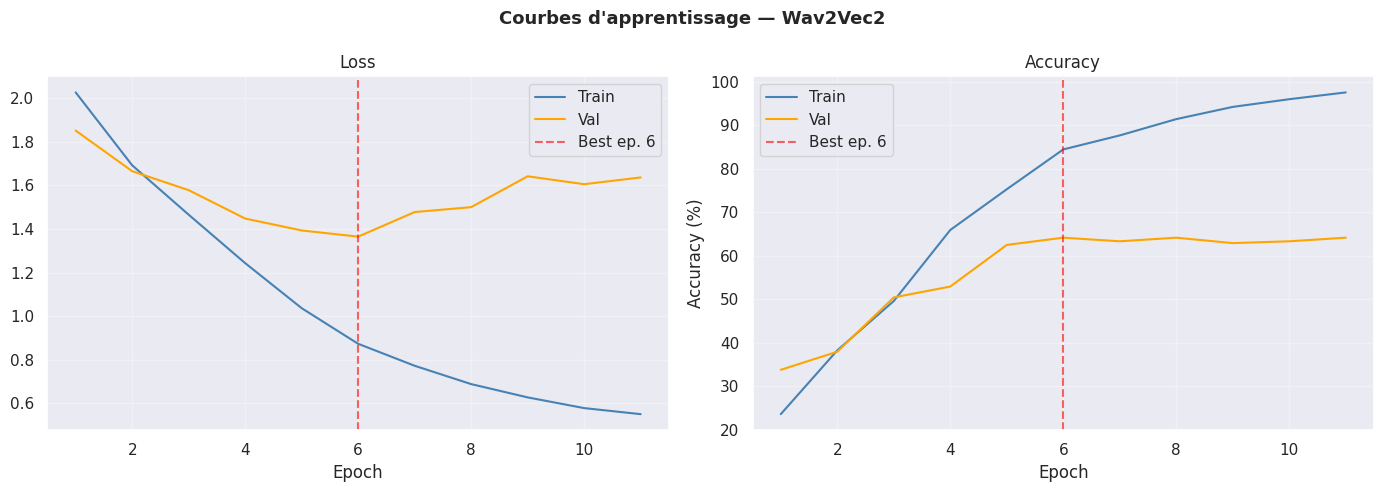

Best epoch : 6 | Best val acc : 64.17%


In [78]:
epochs_range = range(1, len(history['train_loss']) + 1)
best_ep      = np.argmin(history['val_loss']) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — Wav2Vec2', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='orange')
axes[0].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='orange')
axes[1].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'courbes_wav2vec2.png'), bbox_inches='tight')
plt.show()
print(f'Best epoch : {best_ep} | Best val acc : {max(history["val_acc"]):.2%}')

---
## 🎯 Cellule 10 — Évaluation Test + Comparaison finale

In [79]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'✅ Meilleur modèle chargé (epoch {checkpoint["epoch"]} | val_acc {checkpoint["val_acc"]:.2%})')

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Évaluation Test'):
        preds = model(batch['input_values'].to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(batch['label'].numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
test_acc  = (all_preds == all_true).mean()

print(f'\n=== Résultats Test Set ===')
print(f'Accuracy : {test_acc:.2%}')
print()
print(classification_report(all_true, all_preds, target_names=EMOTIONS,
                             digits=3, zero_division=0))

print('=' * 48)
print(f'  CNN de base          : 50.83%')
print(f'  CNN + SpecAugment    : 52.50%')
print(f'  CNN + LSTM           : 50.83%')
print(f'  Wav2Vec2 (fine-tuné) : {test_acc:.2%}  ← actuel')
print('=' * 48)

✅ Meilleur modèle chargé (epoch 6 | val_acc 64.17%)


Évaluation Test:   0%|          | 0/30 [00:00<?, ?it/s]


=== Résultats Test Set ===
Accuracy : 70.83%

              precision    recall  f1-score   support

       angry      0.960     0.750     0.842        32
        calm      0.686     0.750     0.716        32
     disgust      0.630     0.906     0.744        32
     fearful      0.821     0.719     0.767        32
       happy      0.789     0.469     0.588        32
     neutral      0.500     0.812     0.619        16
         sad      0.867     0.406     0.553        32
   surprised      0.630     0.906     0.744        32

    accuracy                          0.708       240
   macro avg      0.736     0.715     0.697       240
weighted avg      0.751     0.708     0.702       240

  CNN de base          : 50.83%
  CNN + SpecAugment    : 52.50%
  CNN + LSTM           : 50.83%
  Wav2Vec2 (fine-tuné) : 70.83%  ← actuel


---
## 🔵 Cellule 11 — Matrice de confusion + UAR

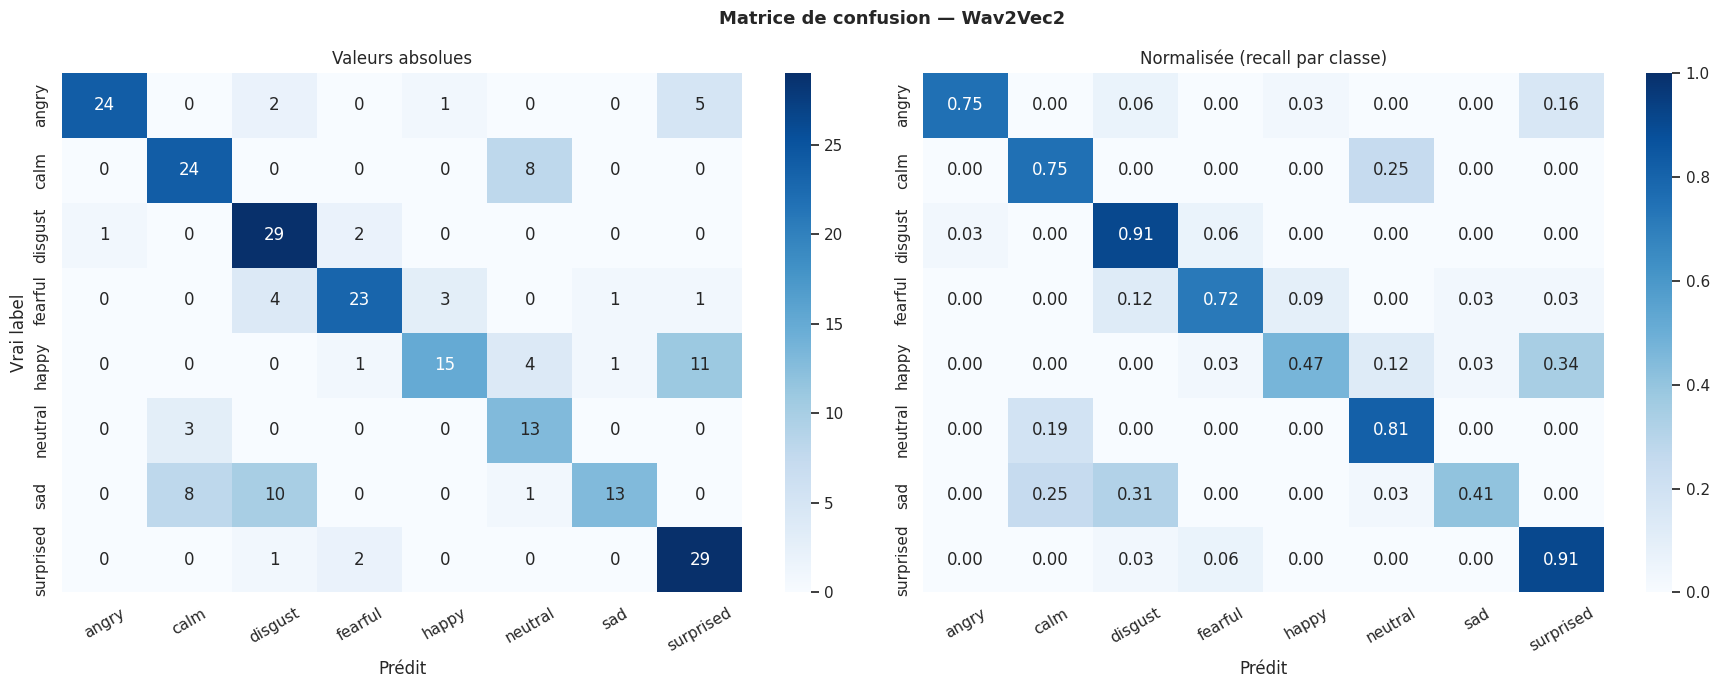


🎯 UAR : 71.48% | Accuracy : 70.83%

  angry        75.00%  ███████████████
  calm         75.00%  ███████████████
  disgust      90.62%  ██████████████████
  fearful      71.88%  ██████████████
  happy        46.88%  █████████
  neutral      81.25%  ████████████████
  sad          40.62%  ████████
  surprised    90.62%  ██████████████████


In [80]:
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrice de confusion — Wav2Vec2', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Valeurs absolues')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Prédit')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalisée (recall par classe)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Prédit')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'confusion_wav2vec2.png'), bbox_inches='tight')
plt.show()

recalls = cm.diagonal() / cm.sum(axis=1)
uar     = recalls.mean()

print(f'\n🎯 UAR : {uar:.2%} | Accuracy : {test_acc:.2%}')
print()
for emo, rec in zip(EMOTIONS, recalls):
    bar = '█' * int(rec * 20)
    print(f'  {emo:<12} {rec:.2%}  {bar}')